In [2]:
# data processing
import pandas as pd
import numpy as np
from collections import Counter
import imblearn
from pylab import *
%matplotlib inline
import rasterio
from classification_aux import inpsectiontocsv

# modelling
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.inspection import permutation_importance
import joblib

In [3]:
# ==========================================================================================
# Load the .csv training dataset created in the preprocessing_clean notebook. 
# ==========================================================================================

#filename = 'RGB_rcgc_dataset.csv'
filename = "data/transformed_chm_data.csv"

df = pd.read_csv(filename)

# -----------------------------------------------------------------------------------------------------------
# activate if not all veg classes are to be used - 
# e.g. for testing clf performance on another dataset that doesn't have all the same classes
#df_all = pd.read_csv(loadpath+filename)
#options = ['lichen', 'rock', 'boradleaf', 'needleleaf', 'deadwood', 'graminoids', 'moss', 'soil']
#df = df_all[df_all['veg_class'].isin(options)]

#df['veg_class'] = df['veg_class'].map({'lichen':1,
#                                       'rock':5,
#                                       'broadlaf':6,
#                                       'needleleaf':7,
#                                       'deadwood':8,
#                                       'graminoids':9,
#                                       'moss':10,
#                                       'soil':11})

# -----------------------------------------------------------------------------------------------------------
## activate code below if all veg classes are to be used
df['veg_class'] = df['veg_class'].map({'lichen':1,
                                       'rock':4,
                                       'broadleaf':5,
                                       'needleleaf':6,
                                       'deadwood':7,
                                       'graminoids':8,
                                       'moss':9,
                                       'soil':10,
                                       'low_green':12,
                                       'dry_branches':13})


df['site'] = df['site'].map({'CG1-8A':1,
                             'CG1-8B':2,
                             'CS3B':3,
                             'CS-46A':4,
                             'CS-46B':5,
                             'CS-59B':6,
                             'CS-96B':7,
                             'CS-103B':8,
                             'CS117B':9,
                             'F3-8A':10,
                             'F3-8B':11,
                             'F3-8C':12,
                             'F3-19B':13,
                             'F3-19C':14,
                             'F3-20A':15,
                             'F3-20B':16,
                             'F3-20C':17,
                             'ZF20-11A':18,
                             'ZF46-15A':19,
                             'ZF46-37A':20})
#df = df.drop(['site', 'Unnamed: 0'], axis = 1)
df.head()

,site,veg_class,R,G,B,rc,gc,chm,bc,rc/gc,...,ExR,ExB,ExGmExR,Ikaw,MGRVI,GLI,Y,L,z_score_Y,z_score_L
0,1,1,0.862745,0.847059,0.788235,0.345369,0.339089,1,0.315542,1.018519,...,0.360784,0.256471,-0.317647,0.045131,-0.018347,0.012896,0.685444,86.277954,0.901666,0.875787
1,1,1,0.909804,0.901961,0.850980,0.341679,0.338733,1,0.319588,1.008696,...,0.371765,0.289412,-0.328627,0.033408,-0.008658,0.012101,0.787592,91.125221,1.338999,1.162117
2,1,1,0.894118,0.886275,0.839216,0.341317,0.338323,1,0.320359,1.008850,...,0.365490,0.288627,-0.326275,0.031674,-0.008810,0.011186,0.757417,89.739293,1.209810,1.080249
3,1,1,0.909804,0.901961,0.858824,0.340675,0.337739,1,0.321586,1.008696,...,0.371765,0.300392,-0.336471,0.028825,-0.008658,0.009879,0.788639,91.172679,1.343483,1.164920
4,1,1,0.937255,0.937255,0.850980,0.343885,0.343885,1,0.312230,1.000000,...,0.374902,0.254118,-0.288627,0.048246,0.000000,0.023555,0.850935,93.923383,1.610195,1.327405


Original class counts:     Counter({6: 6422, 12: 4442, 10: 2404, 9: 1898, 5: 1878, 1: 1590, 13: 1286, 8: 1211, 7: 1056, 4: 707})
Resampled class count (training split):    Counter({10: 5146, 12: 5146, 8: 5146, 1: 5146, 6: 5146, 9: 5146, 13: 5146, 5: 5146, 4: 5146, 7: 5146})
0.9388262728332686
0.7281065734876611
                  0
gc         0.128440
chm        0.115962
rc/gc      0.097419
rc+gc      0.092229
bc         0.091837
rc         0.082167
z_score_L  0.069404
z_score_Y  0.067447
G          0.054839
L          0.053098
Y          0.052731
B          0.049635
R          0.044794


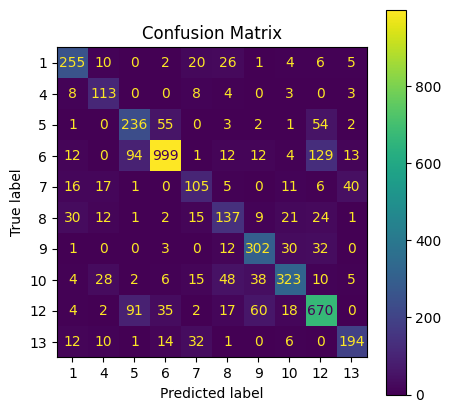

In [4]:
# ==========================================================================================
# Training RF classifier using different combinations of features and hyperparameters
# ==========================================================================================

# Line below shows all available features for classifier training. It's possible to select all or only a few.
#selection = ['R', 'G', 'B', 'rc', 'gc', 'chm', 'bc', 'rc/gc', 'L', 'Y', 'rc+gc', 'z_score_Y', 'z_score_L', 'ExG', 'ExR', 'ExB', 'ExGmExR', 'Ikaw', 'MGRVI', 'GLI']
# -----------------------------------------------------------------------------------------------------------
run = 'run6_orthotest_500-15'
selection = ['R', 'G', 'B', 'rc', 'gc', 'chm', 'bc', 'rc/gc', 'rc+gc', 'L', 'Y', 'z_score_Y', 'z_score_L']

# -----------------------------------------------------------------------------------------------------------
# count labelled data per class - should be similar for each class
c_og = Counter(df.veg_class)
print('Original class counts:     ' + str(c_og))

# -----------------------------------------------------------------------------------------------------------
# Split into train/test sets
y = df.veg_class
X = df[selection]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2)

# -----------------------------------------------------------------------------------------------------------
# oversample w synthetic minority oversampling to balance classes
under = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
X_res, y_res = under.fit_resample(X_train, y_train)
print('Resampled class count (training split):    ' +   str(Counter(y_res)))

# -----------------------------------------------------------------------------------------------------------
# Train RF classifier
clf=RandomForestClassifier(n_estimators=500, max_depth=15)
clf.fit(X_res, y_res)

# -----------------------------------------------------------------------------------------------------------
# Prediction
preds = clf.predict(X_test)

# -----------------------------------------------------------------------------------------------------------
# Inspect performance parameters: training and testing scores, confusion matrix, and feature importance

print (clf.score(X_res, y_res))
print(clf.score(X_test, y_test))

ax1 = plt.figure(figsize=(5,5)).add_subplot(111)
cf_matrix = confusion_matrix(y_test, preds,  labels = clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=clf.classes_)
disp.plot(ax = ax1)
plt.title('Confusion Matrix')

feature_importance = pd.DataFrame(clf.feature_importances_, index=X_res.columns).sort_values(by=0, ascending=False)
print(feature_importance)

# -----------------------------------------------------------------------------------------------------------
# save inspection results to csv output file and confusion matrix to figure
savepath = 'data/clfs/clf_performance/'
savename='%s.csv' % run
inpsectiontocsv(savepath=savepath, savename=savename, selection=selection, clf=clf, cf_matrix=cf_matrix, 
                training_data=[X_res, y_res], testing_data=[X_test, y_test])

figname='cfm_%s.png' % run
savefig(savepath+figname, dpi=150, bbox_inches='tight')

[ 2  0  9 10  1  3  6  8 12 11  7  4  5]


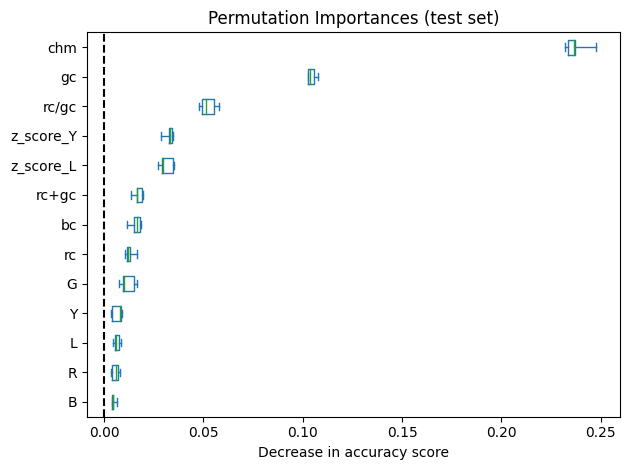

In [5]:
# ==========================================================================================
# Calculate permutation matrix and save figure
# ==========================================================================================
perm_importance = permutation_importance(clf, X_test, y_test)
sorted_idx = perm_importance.importances_mean.argsort()
print(sorted_idx)
importances = pd.DataFrame(
    perm_importance.importances[sorted_idx].T,
    columns=X.columns[sorted_idx],
)

ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
figname='perm_%s.png' % run
savefig(savepath+figname, dpi=150, bbox_inches='tight')

In [6]:
# ==========================================================================================
# save classifier in object 
# ==========================================================================================

# Add columns attribute to classifier. 
# This is important information as .tifs that should be classified need to have the same features and in the same order
clf.col_names=X.columns

# -----------------------------------------------------------------------------------------------------------
# !! careful this can make objects of several GB size
outpath = 'data/clfs/'
outfile = 'clf_%s_TEST.pkl' % run
joblib.dump(clf, outpath+outfile) 

['data/clfs/clf_run6_orthotest_500-15_TEST.pkl']